## Этап 1. Исследовательский анализ (EDA)

In [1]:
import os

DATA_ROOT = 'dataset/'
SPLITS = ['train', 'val', 'test']

for split in SPLITS:
    img_dir = os.path.join(DATA_ROOT, 'img', split)
    mask_dir = os.path.join(DATA_ROOT, 'labels', split)
    
    if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
        print(f"⚠️ Папка для сплита {split} не найдена. Пропускаем.")
        continue
        
    # Читаем файлы и убираем расширения для точного сравнения имен
    img_files = {os.path.splitext(f)[0]: f for f in os.listdir(img_dir) if not f.startswith('.')}
    mask_files = {os.path.splitext(f)[0]: f for f in os.listdir(mask_dir) if not f.startswith('.')}
    
    # Ищем нестыковки
    images_without_masks = set(img_files.keys()) - set(mask_files.keys())
    masks_without_images = set(mask_files.keys()) - set(img_files.keys())
    
    print(f"\n=== Проверка сплита: {split.upper()} ===")
    print(f"Всего картинок: {len(img_files)} | Всего масок: {len(mask_files)}")
    
    if images_without_masks:
        print(f"❌ Картинки без масок ({len(images_without_masks)} шт.):")
        for name in list(images_without_masks)[:5]: # выведем первые 5
            print(f"  - {img_files[name]}")
            
    if masks_without_images:
        print(f"❌ Маски без картинок ({len(masks_without_images)} шт.):")
        for name in list(masks_without_images)[:5]:
            print(f"  - {mask_files[name]}")
            
    if not images_without_masks and not masks_without_images:
        print("✅ Сплит полностью синхронизирован. Ошибок парности нет.")



=== Проверка сплита: TRAIN ===
Всего картинок: 200 | Всего масок: 200
✅ Сплит полностью синхронизирован. Ошибок парности нет.

=== Проверка сплита: VAL ===
Всего картинок: 120 | Всего масок: 120
✅ Сплит полностью синхронизирован. Ошибок парности нет.

=== Проверка сплита: TEST ===
Всего картинок: 120 | Всего масок: 120
✅ Сплит полностью синхронизирован. Ошибок парности нет.


In [2]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

DATA_ROOT = 'dataset/'
SPLITS = ['train', 'val', 'test']

global_unique_classes = set()
split_classes = {}

print("🔎 Сканируем маски для определения реального количества классов...")

for split in SPLITS:
    mask_dir = os.path.join(DATA_ROOT, 'labels', split)
    if not os.path.exists(mask_dir):
        continue
        
    files = [f for f in os.listdir(mask_dir) if f.lower().endswith('.png')]
    split_set = set()
    
    for f_name in tqdm(files, desc=f"Анализ {split}"):
        mask_path = os.path.join(mask_dir, f_name)
        
        # Читаем маску как Grayscale numpy-массив
        mask_arr = np.array(Image.open(mask_path))
        unique_in_file = np.unique(mask_arr)
        
        split_set.update(unique_in_file)
        global_unique_classes.update(unique_in_file)
        
    split_classes[split] = sorted(list(split_set))

print("\n=== РЕЗУЛЬТАТЫ АНАЛИЗА КЛАССОВ ===")
print(f"Все уникальные ID пикселей, найденные в датасете: {sorted(list(global_unique_classes))}")
print(f"Итого потенциальных классов (включая фон): {len(global_unique_classes)}")

for split, classes in split_classes.items():
    print(f"  - В сплите [{split.upper()}] присутствуют ID: {classes}")


🔎 Сканируем маски для определения реального количества классов...


Анализ test: 100%|██████████| 120/120 [00:01<00:00, 88.37it/s]


=== РЕЗУЛЬТАТЫ АНАЛИЗА КЛАССОВ ===
Все уникальные ID пикселей, найденные в датасете: [0, 1, 2]
Итого потенциальных классов (включая фон): 3
  - В сплите [TRAIN] присутствуют ID: [0, 1, 2]
  - В сплите [VAL] присутствуют ID: [0, 1, 2]
  - В сплите [TEST] присутствуют ID: [0, 1, 2]


In [6]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

DATA_ROOT = 'dataset/'
SPLITS = ['train', 'val', 'test']

empty_masks_report = {}

print("🔎 Сканирование масок на наличие пустых сэмплов...")

for split in SPLITS:
    mask_dir = os.path.join(DATA_ROOT, 'labels', split)
    if not os.path.exists(mask_dir):
        continue
        
    files = [f for f in os.listdir(mask_dir) if f.lower().endswith('.png')]
    empty_files = []
    
    for f_name in tqdm(files, desc=f"Анализ {split}"):
        mask_path = os.path.join(mask_dir, f_name)
        
        # Загружаем маску
        mask_arr = np.array(Image.open(mask_path))
        
        # Проверяем, равен ли максимум нулю (значит, других классов нет)
        if mask_arr.max() == 0:
            empty_files.append(f_name)
            
    empty_masks_report[split] = empty_files

print("\n=== ОТЧЕТ ПО ПУСТЫМ МАСКАМ ===")
for split, empty_list in empty_masks_report.items():
    total_masks = len([f for f in os.listdir(os.path.join(DATA_ROOT, 'labels', split)) if f.lower().endswith('.png')])
    pct = (len(empty_list) / total_masks * 100) if total_masks > 0 else 0
    print(f"Сплит [{split.upper()}]: Найдено {len(empty_list)} из {total_masks} пустых масок ({pct:.2f}%)")
    if empty_list:
        print(f"  - Первые 5 пустых файлов: {empty_list[:5]}")


🔎 Сканирование масок на наличие пустых сэмплов...


Анализ test: 100%|██████████| 120/120 [00:00<00:00, 704.29it/s]



=== ОТЧЕТ ПО ПУСТЫМ МАСКАМ ===
Сплит [TRAIN]: Найдено 0 из 200 пустых масок (0.00%)
Сплит [VAL]: Найдено 0 из 120 пустых масок (0.00%)
Сплит [TEST]: Найдено 0 из 120 пустых масок (0.00%)


In [9]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

DATA_ROOT = 'dataset/'
SPLITS = ['train', 'val', 'test']
MIN_OBJECT_AREA = 20  # Порог в пикселях для поиска шума разметки
TARGET_CLASSES = [1, 2]  # Инициализация целевых классов объектов

report = {split: {'mismatch_size': [], 'noisy_masks': [], 'classes_per_file': {}} for split in SPLITS}

print("🔎 Запуск глубокого аудита геометрии и контуров...")

for split in SPLITS:
    img_dir = os.path.join(DATA_ROOT, 'img', split)
    mask_dir = os.path.join(DATA_ROOT, 'labels', split)
    
    if not os.path.exists(img_dir):
        continue
        
    img_files = sorted([f for f in os.listdir(img_dir) if not f.startswith('.')])
    
    for f_name in tqdm(img_files, desc=f"Аудит {split}"):
        base_name, _ = os.path.splitext(f_name)
        mask_path = os.path.join(mask_dir, base_name + '.png')
        img_path = os.path.join(img_dir, f_name)
        
        if not os.path.exists(mask_path):
            continue
            
        # 1. Проверка физических размеров
        with Image.open(img_path) as img:
            img_w, img_h = img.size
        with Image.open(mask_path) as mask:
            mask_w, mask_h = mask.size
            
        if (img_w != mask_w) or (img_h != mask_h):
            report[split]['mismatch_size'].append((f_name, f"Img: {img_w}x{img_h}, Mask: {mask_w}x{mask_h}"))
            continue
            
        # 2. Анализ связных областей (поиск шума и контуров)
        mask_arr = np.array(Image.open(mask_path))
        
        # Проверяем каждый целевой класс (1 и 2)
        has_noise = False
        for class_id in TARGET_CLASSES:
            binary_mask = (mask_arr == class_id).astype(np.uint8)
            if np.sum(binary_mask) == 0:
                continue
                
            # Ищем изолированные объекты этого класса
            num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask)
            
            # Проверяем площади найденных островков (минуя фон под индексом 0)
            for i in range(1, num_labels):
                area = stats[i, cv2.CC_STAT_AREA]
                if area < MIN_OBJECT_AREA:
                    has_noise = True
                    break
                    
        if has_noise:
            report[split]['noisy_masks'].append(f_name)

# --- ИТОГОВЫЙ ОТЧЕТ ---
print("\n=== ОТЧЕТ О СКРЫТЫХ ОШИБКАХ ===")
for split in SPLITS:
    print(f"\nСплит [{split.upper()}]:")
    print(f"  - Несовпадений размеров (Картинка VS Маска): {len(report[split]['mismatch_size'])}")
    if report[split]['mismatch_size']:
        print(f"    Примеры: {report[split]['mismatch_size'][:3]}")
        
    print(f"  - Масок с «шумной» или битой разметкой (одиночные пиксели): {len(report[split]['noisy_masks'])}")
    if report[split]['noisy_masks']:
        print(f"    Примеры файлов: {report[split]['noisy_masks'][:5]}")


🔎 Запуск глубокого аудита геометрии и контуров...


Аудит train:   0%|          | 0/200 [00:00<?, ?it/s]

Аудит test: 100%|██████████| 120/120 [00:03<00:00, 32.84it/s]


=== ОТЧЕТ О СКРЫТЫХ ОШИБКАХ ===

Сплит [TRAIN]:
  - Несовпадений размеров (Картинка VS Маска): 0
  - Масок с «шумной» или битой разметкой (одиночные пиксели): 15
    Примеры файлов: ['000000016206_4014.jpg', '000000024497_3808.jpg', '000000028253_7169.jpg', '000000121530_5761.jpg', '000000223640_3774.jpg']

Сплит [VAL]:
  - Несовпадений размеров (Картинка VS Маска): 0
  - Масок с «шумной» или битой разметкой (одиночные пиксели): 2
    Примеры файлов: ['000000026310_3053.jpg', '000000209731_4128.jpg']

Сплит [TEST]:
  - Несовпадений размеров (Картинка VS Маска): 0
  - Масок с «шумной» или битой разметкой (одиночные пиксели): 4
    Примеры файлов: ['000000258129_3143.jpg', '000000324772_4097.jpg', '000000352558_5800.jpg', '000000358545_4807.jpg']


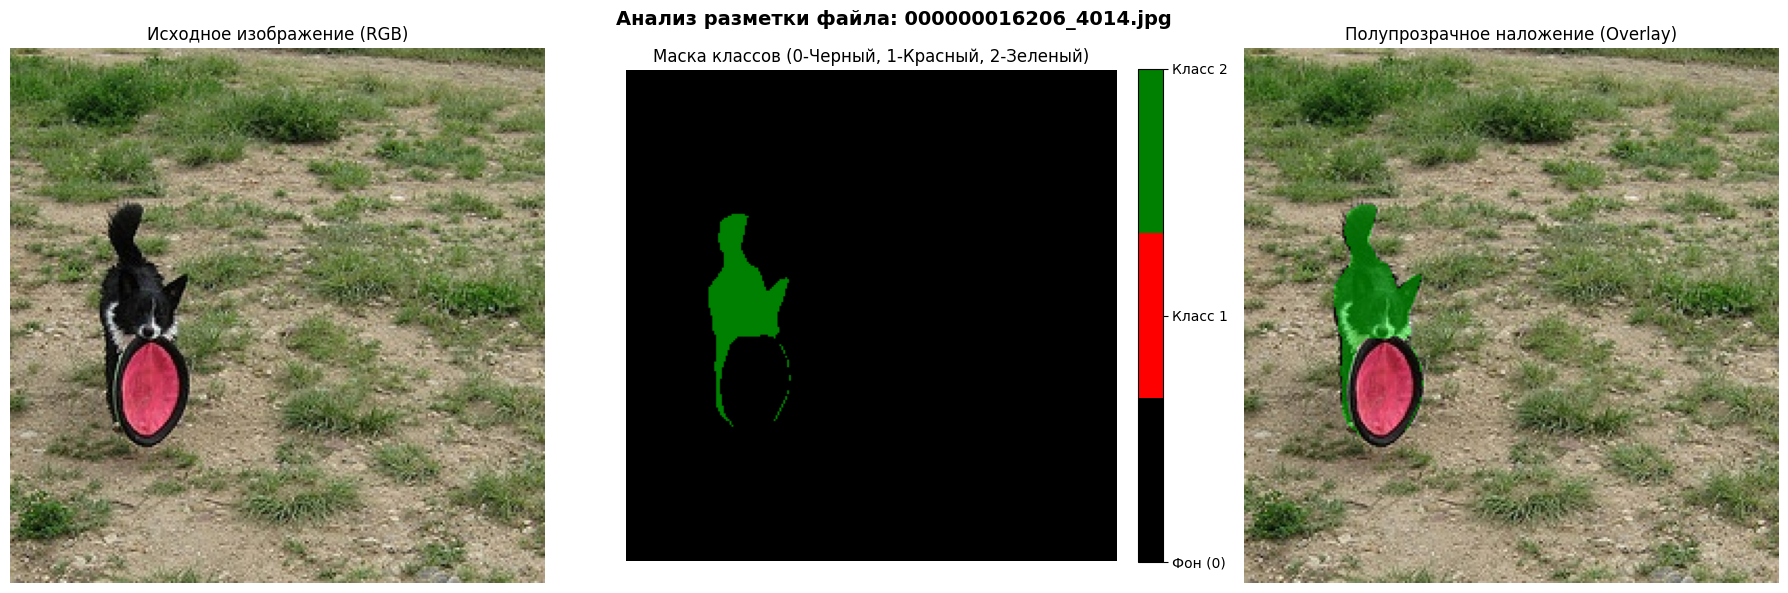

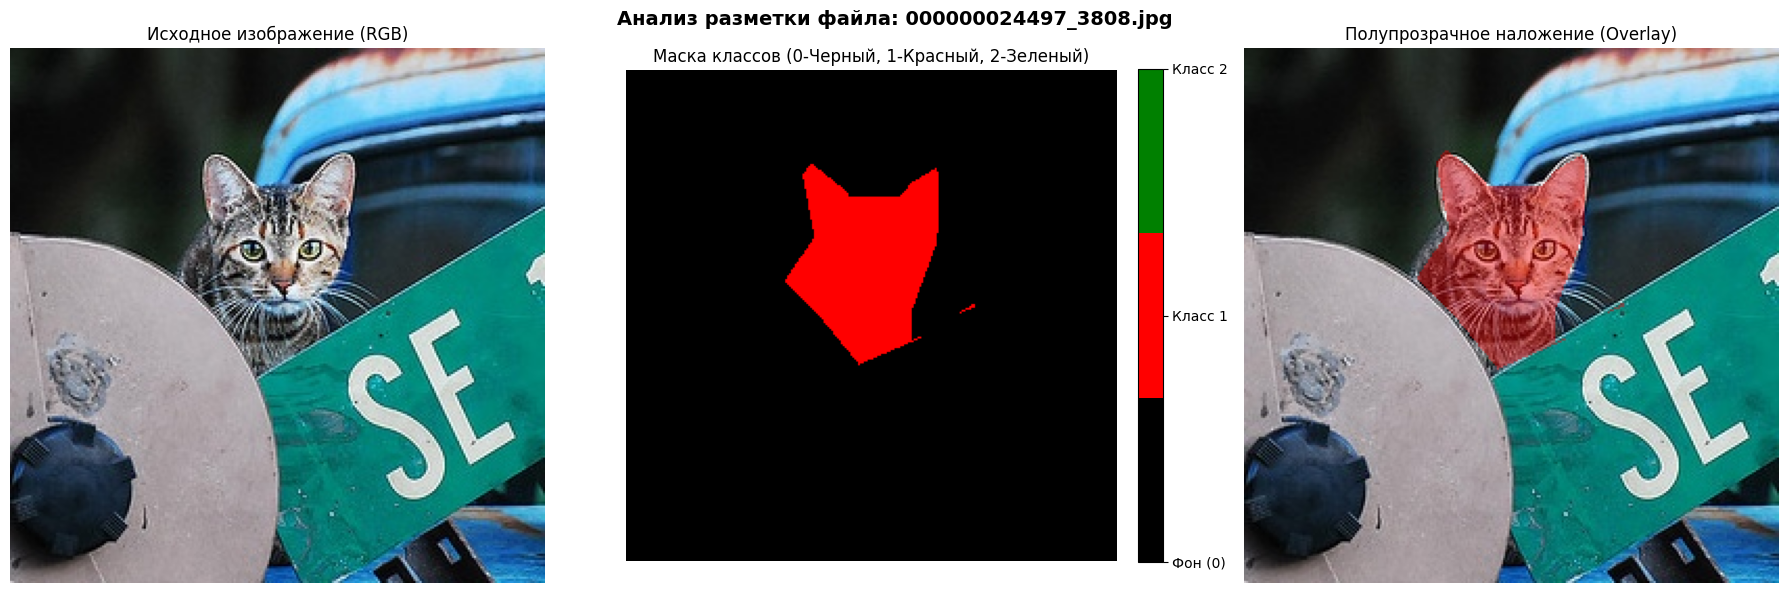

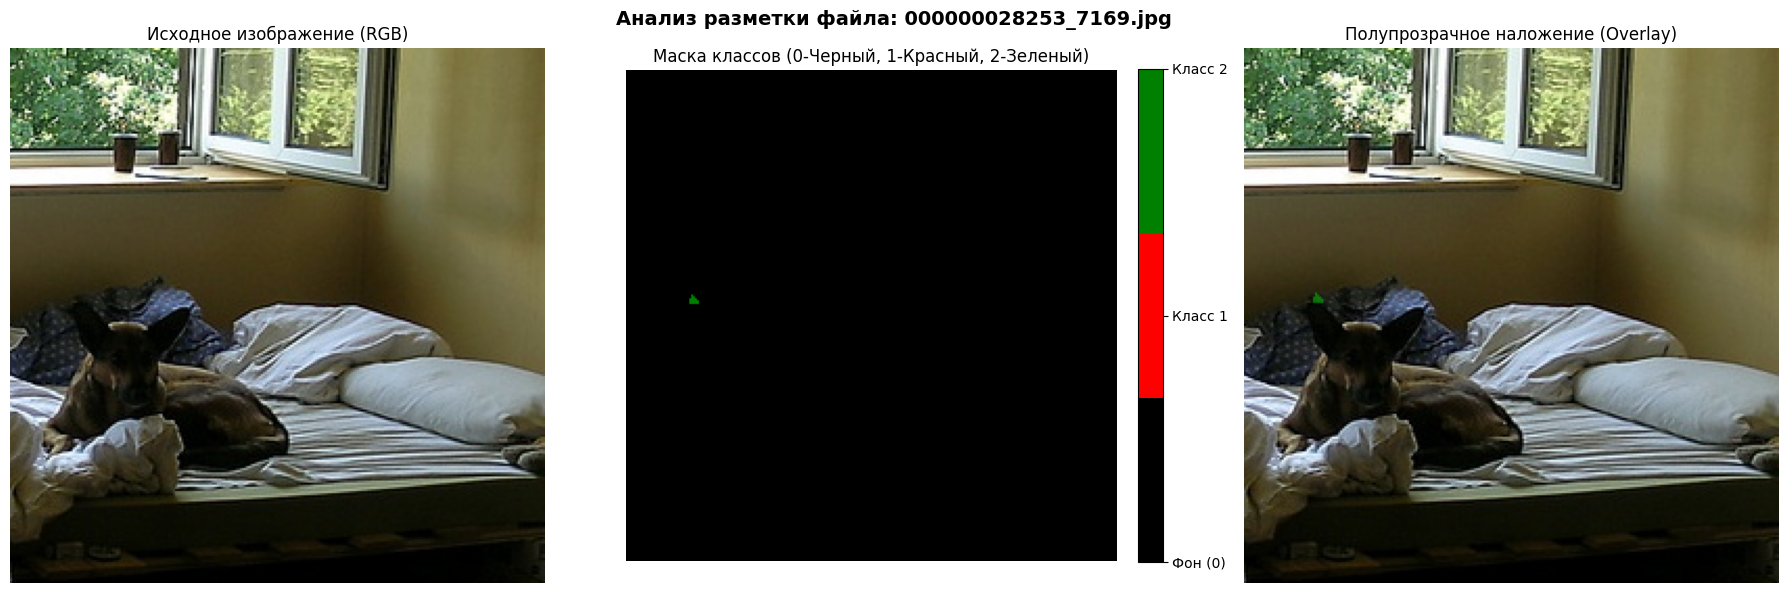

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image

DATA_ROOT = 'dataset/'
SPLIT = 'train'

# Возьмем первые 3 проблемных файла, которые нашел наш аудит
PROBLEMATIC_FILES = ['000000016206_4014.jpg', '000000024497_3808.jpg', '000000028253_7169.jpg']

img_dir = os.path.join(DATA_ROOT, 'img', SPLIT)
mask_dir = os.path.join(DATA_ROOT, 'labels', SPLIT)

# Создаем кастомную контрастную палитру для 3 классов (0, 1, 2)
# Класс 0 (Фон) - черный, Класс 1 - красный, Класс 2 - зеленый
CUSTOM_CMAP = mcolors.ListedColormap(['black', 'red', 'green'])

# Цвета для BGR-наложения через OpenCV (Класс 1 -> Красный, Класс 2 -> Зеленый)
COLOR_MAP_BGR = {
    1: (0, 0, 255),    
    2: (0, 255, 0)
}

for f_name in PROBLEMATIC_FILES:
    base_name, _ = os.path.splitext(f_name)
    img_path = os.path.join(img_dir, f_name)
    mask_path = os.path.join(mask_dir, base_name + '.png')
    
    if not os.path.exists(img_path) or not os.path.exists(mask_path):
        print(f"Файл {f_name} или его маска не найдены по указанному пути.")
        continue
        
    # 1. Загрузка данных
    # Картинку читаем через OpenCV и переводим в RGB для Matplotlib
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Маску читаем как Grayscale массив
    mask_arr = np.array(Image.open(mask_path))
    
    # 2. Создание полупрозрачного наложения (Overlay)
    overlay = img_bgr.copy()
    for class_id, color in COLOR_MAP_BGR.items():
        overlay[mask_arr == class_id] = color
    # Смешиваем: 60% исходного фото, 40% цветной маски
    overlay_rgb = cv2.cvtColor(cv2.addWeighted(overlay, 0.4, img_bgr, 0.6, 0), cv2.COLOR_BGR2RGB)
    
    # 3. Отрисовка через Matplotlib
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Анализ разметки файла: {f_name}", fontsize=14, fontweight='bold')
    
    # Левый график: Исходное изображение
    axes[0].imshow(img_rgb)
    axes[0].set_title("Исходное изображение (RGB)")
    axes[0].axis('off')
    
    # Средний график: Чистая маска классов
    # vmin=0, vmax=2 фиксируют палитру, чтобы цвета не инвертировались при отсутствии классов
    im = axes[1].imshow(mask_arr, cmap=CUSTOM_CMAP, vmin=0, vmax=2)
    axes[1].set_title("Маска классов (0-Черный, 1-Красный, 2-Зеленый)")
    axes[1].axis('off')
    
    # Правый график: Наложение маски на фото
    axes[2].imshow(overlay_rgb)
    axes[2].set_title("Полупрозрачное наложение (Overlay)")
    axes[2].axis('off')
    
    # Добавляем цветовую шкалу (Colorbar) для наглядности маски
    cbar = fig.colorbar(im, ax=axes[1], ticks=[0, 1, 2], fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels(['Фон (0)', 'Класс 1', 'Класс 2'])
    
    plt.tight_layout()
    plt.show()


In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
from tqdm import tqdm

DATA_ROOT = 'dataset/'
SPLITS = ['train', 'val', 'test']
BACKGROUND_THRESHOLD = 99.5  # Порог процента фона
MAX_PLOTS_PER_SPLIT = 5      # Сколько картинок отрисовать для каждого сплита

CUSTOM_CMAP = mcolors.ListedColormap(['black', 'red', 'green'])
COLOR_MAP_BGR = {1: (0, 0, 255), 2: (0, 255, 0)}

print(f"🔎 Сканирование датасета на маски, где фон >= {BACKGROUND_THRESHOLD}%...")

for split in SPLITS:
    img_dir = os.path.join(DATA_ROOT, 'img', split)
    mask_dir = os.path.join(DATA_ROOT, 'labels', split)
    
    if not os.path.exists(mask_dir) or not os.path.exists(img_dir):
        continue
        
    mask_files = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith('.png')])
    high_bg_masks = []
    
    for f_name in tqdm(mask_files, desc=f"Анализ {split}"):
        mask_path = os.path.join(mask_dir, f_name)
        
        try:
            mask_arr = np.array(Image.open(mask_path))
            total_pixels = mask_arr.size
            
            if total_pixels == 0:
                continue
                
            bg_pixels = np.sum(mask_arr == 0)
            bg_percentage = (bg_pixels / total_pixels) * 100
            
            if bg_percentage >= BACKGROUND_THRESHOLD:
                high_bg_masks.append((f_name, bg_percentage, mask_arr))
                
        except Exception as e:
            print(f"Ошибка чтения {f_name}: {e}")

    total_masks = len(mask_files)
    count_high_bg = len(high_bg_masks)
    pct_of_total = (count_high_bg / total_masks * 100) if total_masks > 0 else 0
    
    print(f"\n--- Результаты по сплиту [{split.upper()}] ---")
    print(f"Всего масок в папке: {total_masks}")
    print(f"📊 Масок с фоном >= {BACKGROUND_THRESHOLD}%: {count_high_bg} ({pct_of_total:.2f}% от всего сплита)")
    
    # === НОВЫЙ БЛОК: Вывод и сохранение полного списка имен файлов ===
    if count_high_bg > 0:
        output_txt = f"high_bg_{split}.txt"
        print(f"📄 Полный список файлов для [{split.upper()}] (сохранен в {output_txt}):")
        
        with open(output_txt, 'w', encoding='utf-8') as txt_file:
            for f_name, bg_p, _ in high_bg_masks:
                name_info = f"{f_name} ({bg_p:.2f}% фона)"
                print(f"  - {name_info}")  # Печать в консоль
                txt_file.write(f"{f_name}\n") # Запись только имени файла в txt

    
    # --- БЛОК ОТРИСОВКИ ПЕРВЫХ 5 ИЗОБРАЖЕНИЙ ---
    if count_high_bg > 0:
        print(f"\n📸 Отрисовка первых {min(MAX_PLOTS_PER_SPLIT, count_high_bg)} изображений...")
        
        for name, bg_p, mask_arr in high_bg_masks[:MAX_PLOTS_PER_SPLIT]:
            base_name, _ = os.path.splitext(name)
            
            img_path = os.path.join(img_dir, base_name + '.jpg')
            if not os.path.exists(img_path):
                img_path = os.path.join(img_dir, base_name + '.jpeg')
                
            if not os.path.exists(img_path):
                print(f"⚠️ Изображение для маски {name} не найдено в {img_dir}")
                continue
                
            img_bgr = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            overlay = img_bgr.copy()
            for class_id, color in COLOR_MAP_BGR.items():
                overlay[mask_arr == class_id] = color
            overlay_rgb = cv2.cvtColor(cv2.addWeighted(overlay, 0.4, img_bgr, 0.6, 0), cv2.COLOR_BGR2RGB)
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            fig.suptitle(f"Сплит: {split.upper()} | Файл: {name} (Фон: {bg_p:.2f}%)", fontsize=12, fontweight='bold')
            
            axes[0].imshow(img_rgb)
            axes[0].set_title("Оригинал")
            axes[0].axis('off')
            
            im = axes[1].imshow(mask_arr, cmap=CUSTOM_CMAP, vmin=0, vmax=2)
            axes[1].set_title("Маска классов")
            axes[1].axis('off')
            
            axes[2].imshow(overlay_rgb)
            axes[2].set_title("Наложение (Overlay)")
            axes[2].axis('off')
            
            cbar = fig.colorbar(im, ax=axes, ticks=[0, 1, 2], fraction=0.046, pad=0.04)
            cbar.ax.set_yticklabels(['Фон (0)', 'Класс 1', 'Класс 2'])
            
            plt.tight_layout()
            plt.show()
            
    print("-" * 50)


🔎 Сканирование датасета на маски, где фон >= 99.5%...


Анализ train: 100%|██████████| 195/195 [00:00<00:00, 549.57it/s]



--- Результаты по сплиту [TRAIN] ---
Всего масок в папке: 195
📊 Масок с фоном >= 99.5%: 0 (0.00% от всего сплита)
--------------------------------------------------


Анализ val: 100%|██████████| 120/120 [00:00<00:00, 465.33it/s]



--- Результаты по сплиту [VAL] ---
Всего масок в папке: 120
📊 Масок с фоном >= 99.5%: 0 (0.00% от всего сплита)
--------------------------------------------------


Анализ test: 100%|██████████| 120/120 [00:00<00:00, 670.02it/s]


--- Результаты по сплиту [TEST] ---
Всего масок в папке: 120
📊 Масок с фоном >= 99.5%: 0 (0.00% от всего сплита)
--------------------------------------------------


In [19]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import pandas as pd

DATA_ROOT = 'dataset/'
SPLITS = ['train', 'val', 'test']
NUM_CLASSES = 3  # Классы: 0, 1, 2

print("🔎 Расчет попиксельного баланса классов по всему датасету...")

for split in SPLITS:
    mask_dir = os.path.join(DATA_ROOT, 'labels', split)
    if not os.path.exists(mask_dir):
        continue
        
    mask_files = [f for f in os.listdir(mask_dir) if f.lower().endswith('.png')]
    class_counts = {i: 0 for i in range(NUM_CLASSES)}
    total_pixels = 0
    
    for f_name in tqdm(mask_files, desc=f"Подсчет пикселей в {split}"):
        mask_path = os.path.join(mask_dir, f_name)
        try:
            mask_arr = np.array(Image.open(mask_path))
            
            # Считаем уникальные значения на этой маске
            unique, counts = np.unique(mask_arr, return_counts=True)
            for cl, cnt in zip(unique, counts):
                if cl in class_counts:
                    class_counts[cl] += cnt
                    total_pixels += cnt
        except Exception as e:
            print(f"Ошибка при чтении {f_name}: {e}")
            
    print(f"\n📊 --- Распределение классов в [{split.upper()}] ---")
    if total_pixels == 0:
        print("Нет данных или маски пустые.")
        continue
        
    for class_id, count in class_counts.items():
        percentage = (count / total_pixels) * 100
        class_name = "Фон (0)" if class_id == 0 else f"Класс {class_id}"
        print(f"  - {class_name}: {count:,} px ({percentage:.3f}%)")
    print("-" * 50)


🔎 Расчет попиксельного баланса классов по всему датасету...


Подсчет пикселей в train: 100%|██████████| 195/195 [00:00<00:00, 237.48it/s]



📊 --- Распределение классов в [TRAIN] ---
  - Фон (0): 11,581,618 px (90.626%)
  - Класс 1: 652,813 px (5.108%)
  - Класс 2: 545,089 px (4.265%)
--------------------------------------------------


Подсчет пикселей в val: 100%|██████████| 120/120 [00:00<00:00, 274.67it/s]



📊 --- Распределение классов в [VAL] ---
  - Фон (0): 7,019,556 px (89.258%)
  - Класс 1: 515,420 px (6.554%)
  - Класс 2: 329,344 px (4.188%)
--------------------------------------------------


Подсчет пикселей в test: 100%|██████████| 120/120 [00:00<00:00, 192.40it/s]


📊 --- Распределение классов в [TEST] ---
  - Фон (0): 7,056,219 px (89.724%)
  - Класс 1: 456,677 px (5.807%)
  - Класс 2: 351,424 px (4.469%)
--------------------------------------------------


## Этап 2. Формирование первичных гипотез

In [4]:
import json

log_file_path = 'work_dirs/pspnet_py/20260724_132610/vis_data/scalars.json'  # Путь к твоему json
max_dice = 0.0
best_iter = 0

with open(log_file_path, 'r') as f:
    for line in f:
        try:
            # MMSeg часто пишет логи построчно
            data = json.loads(line.strip())
            
            # Проверяем наличие метрики (в mmseg v1.x метрика может называться 'mDice' или 'aDice')
            if 'mDice' in data:
                current_dice = data['mDice']
                if current_dice > max_dice:
                    max_dice = current_dice
                    best_iter = data.get('iter', data.get('step', 'unknown'))
        except json.JSONDecodeError:
            continue

print(f"🔥 Best mDice: {max_dice} (at iteration {best_iter})")


🔥 Best mDice: 81.97 (at iteration 240)


In [5]:
import json

log_file_path = 'work_dirs/pspnet_py_v2/20260724_152137/vis_data/scalars.json'  # Путь к твоему json
max_dice = 0.0
best_iter = 0

with open(log_file_path, 'r') as f:
    for line in f:
        try:
            # MMSeg часто пишет логи построчно
            data = json.loads(line.strip())
            
            # Проверяем наличие метрики (в mmseg v1.x метрика может называться 'mDice' или 'aDice')
            if 'mDice' in data:
                current_dice = data['mDice']
                if current_dice > max_dice:
                    max_dice = current_dice
                    best_iter = data.get('iter', data.get('step', 'unknown'))
        except json.JSONDecodeError:
            continue

print(f"🔥 Best mDice: {max_dice} (at iteration {best_iter})")


🔥 Best mDice: 78.43 (at iteration 144)
